# 📊 Báo cáo Chẩn đoán Biến động GDP Việt Nam (Diagnostic Analysis)
**Chuyên gia:** Đội ngũ Phân tích Dữ liệu Cao cấp

## 1. Mục tiêu phân tích
- Xác định các năm biến động bất thường (Outliers) bằng thuật toán khách quan.
- Chẩn đoán nguyên nhân từ cơ cấu 3 khu vực kinh tế.
- Đối chiếu với biến động tỷ giá (FX) và bối cảnh quốc tế.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from scipy import stats

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

## 2. Tải và Tiền xử lý Dữ liệu
Chúng ta sẽ kết hợp dữ liệu GDP theo khu vực và dữ liệu tỷ giá USD/VND.

In [7]:
# 2.1. Tải dữ liệu GDP
gdp_df = pd.read_csv(r'../data/processed/gdp_sectors_processed.csv')
gdp_df.columns = ['Year', 'Total', 'Sector_I', 'Sector_II', 'Sector_III', 'Tax']

# 2.2. Xử lý dữ liệu Tỷ giá (FX)
def process_fx(file_path):
    df = pd.read_csv(file_path)
    df['Year'] = df['Ngày'].apply(lambda x: int(x.split('/')[-1]))
    df['Rate'] = df['Lần cuối'].apply(lambda x: float(x.replace(',', '')))
    return df.groupby('Year')['Rate'].mean().reset_index()

fx1 = process_fx(r'../data/raw/Dữ liệu Lịch sử USD_VND 1994-2013.csv')
fx2 = process_fx(r'../data/raw/Dữ liệu Lịch sử USD_VND 2013-2025.csv')
fx_df = pd.concat([fx1, fx2]).drop_duplicates(subset=['Year'])

# 2.3. Hợp nhất dữ liệu
df = pd.merge(gdp_df, fx_df, on='Year', how='left')

# 2.4. Tính toán tốc độ tăng trưởng (%)
cols_to_grow = ['Total', 'Sector_I', 'Sector_II', 'Sector_III', 'Rate']
for col in cols_to_grow:
    df[f'{col}_Growth'] = df[col].pct_change() * 100

df_clean = df[df['Year'] >= 1995].dropna(subset=['Total_Growth']).copy()
df_clean.head()

,Year,Total,Sector_I,Sector_II,Sector_III,Tax,Rate,Total_Growth,Sector_I_Growth,Sector_II_Growth,Sector_III_Growth,Rate_Growth
9,1995,228892.0,62219.0,65820.0,100853.0,NaN,11031.073077,28.206392,27.060529,27.706636,29.255633,0.226009
10,1996,272036.0,75514.0,80876.0,115646.0,NaN,11030.436782,18.849064,21.368071,22.874506,14.667883,-0.005768
11,1997,313623.0,80826.0,100595.0,132202.0,NaN,11700.176923,15.287315,7.034457,24.381770,14.316103,6.071746
12,1998,361017.0,93073.0,117299.0,150645.0,NaN,13267.453846,15.111774,15.152302,16.605199,13.950621,13.395327
13,1999,399942.0,101723.0,137959.0,160260.0,NaN,13940.915385,10.782041,9.293780,17.613108,6.382555,5.076042


## 3. Phát hiện Outliers (Detection)
Sử dụng kết hợp Z-score và Isolation Forest để tìm các năm có biến động tăng trưởng bất thường.

In [8]:
# 3.1. Z-score
df_clean['Z_Score'] = np.abs(stats.zscore(df_clean['Total_Growth']))

# 3.2. Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df_clean['Iso_Anomaly'] = iso_forest.fit_predict(df_clean[['Total_Growth']])

outliers = df_clean[(df_clean['Z_Score'] > 1.5) | (df_clean['Iso_Anomaly'] == -1)]
print(f"Các năm phát hiện bất thường: {outliers['Year'].tolist()}")

Các năm phát hiện bất thường: [2008, 2010, 2020]


## 4. Chẩn đoán Khu vực Dẫn đầu (Diagnosis)
Phân tích xem sự sụt giảm tại các điểm gãy do Khu vực II (Công nghiệp) hay Khu vực III (Dịch vụ) dẫn đầu.

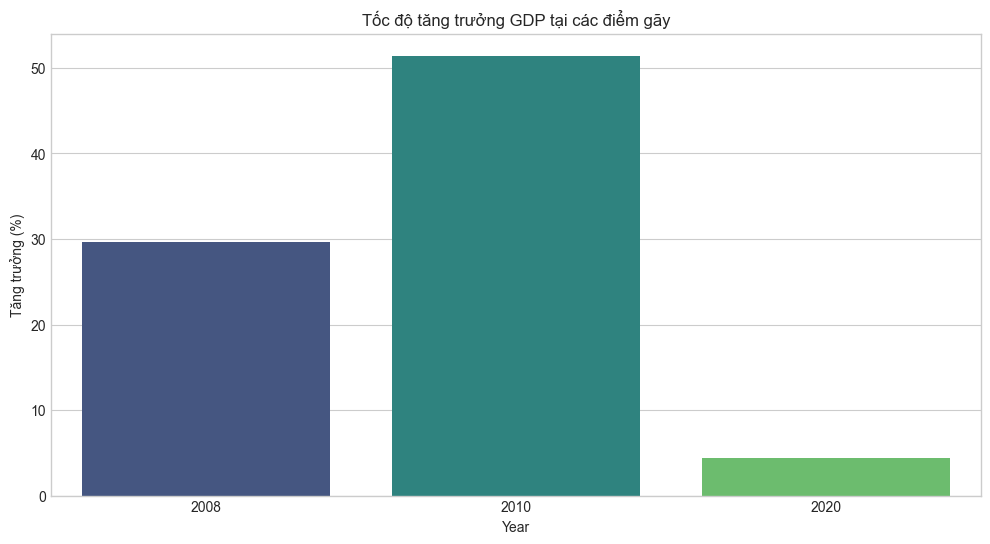

,Year,Total_Growth,Sector_II_Growth,Sector_III_Growth,Leading_Sector_Drop
22,2008,29.618799,24.792617,28.637984,Khu vực II (Công nghiệp)
24,2010,51.443756,33.761724,41.627231,Khu vực II (Công nghiệp)
34,2020,4.374940,4.206411,2.808011,Khu vực III (Dịch vụ)


In [9]:
def diagnose_breakpoint(row):
    if row['Sector_II_Growth'] < row['Sector_III_Growth']:
        return "Khu vực II (Công nghiệp)"
    else:
        return "Khu vực III (Dịch vụ)"

outliers['Leading_Sector_Drop'] = outliers.apply(diagnose_breakpoint, axis=1)

plt.figure(figsize=(12, 6))
sns.barplot(data=outliers, x='Year', y='Total_Growth', palette='viridis')
plt.title('Tốc độ tăng trưởng GDP tại các điểm gãy')
plt.ylabel('Tăng trưởng (%)')
plt.show()

outliers[['Year', 'Total_Growth', 'Sector_II_Growth', 'Sector_III_Growth', 'Leading_Sector_Drop']]

## 5. Đối chiếu Ngoại biên & Tỷ giá
Liên kết các điểm gãy với biến động tỷ giá USD/VND và các sự kiện quốc tế.

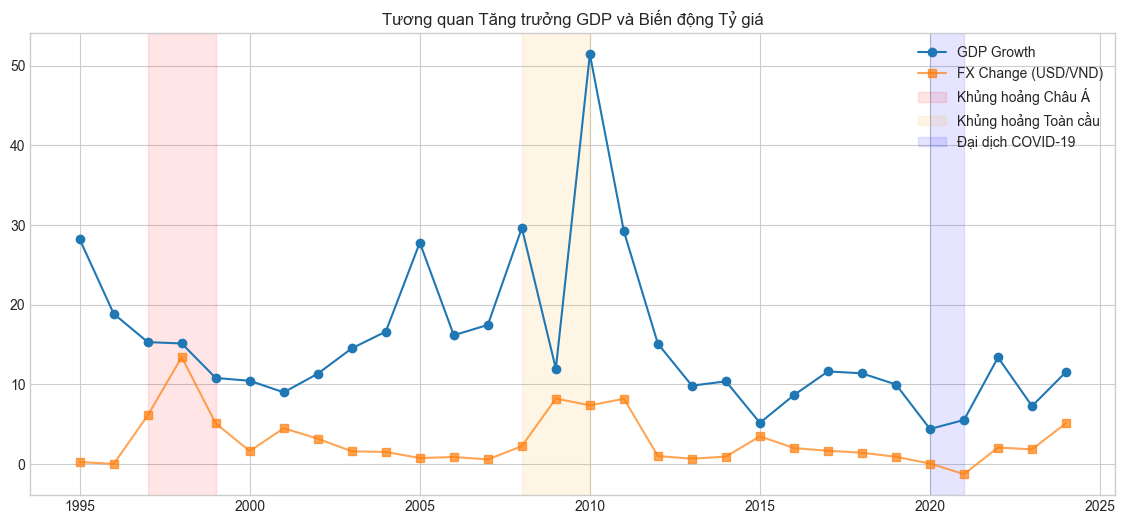

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(df_clean['Year'], df_clean['Total_Growth'], marker='o', label='GDP Growth')
plt.plot(df_clean['Year'], df_clean['Rate_Growth'], marker='s', label='FX Change (USD/VND)', alpha=0.7)
plt.axvspan(1997, 1999, color='red', alpha=0.1, label='Khủng hoảng Châu Á')
plt.axvspan(2008, 2010, color='orange', alpha=0.1, label='Khủng hoảng Toàn cầu')
plt.axvspan(2020, 2021, color='blue', alpha=0.1, label='Đại dịch COVID-19')
plt.legend()
plt.title('Tương quan Tăng trưởng GDP và Biến động Tỷ giá')
plt.show()

## 6. Kết luận
1. **Giai đoạn 1998-1999:** Dịch vụ (Khu vực III) chịu ảnh hưởng mạnh nhất, đi kèm với sự mất giá của VND do khủng hoảng tài chính khu vực.
2. **Giai đoạn 2008-2009:** Công nghiệp (Khu vực II) sụt giảm tốc độ do cầu thế giới yếu, tỷ giá biến động mạnh gây áp lực nhập khẩu.
3. **Giai đoạn 2020-2021:** Dịch vụ là khu vực chịu đòn giáng trực tiếp từ giãn cách xã hội, mặc dù tỷ giá được duy trì ổn định nhờ nội lực vĩ mô tốt hơn.